In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd

# from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.data_objects.iir_filter_data import IirFilterData

from specula.lib.make_mask import make_mask
from specula.mmlib.save_iir_filter import plot_iir_tfs

2026-06-25 09:52:19,559 [WARNING]: [specula]: Cupy import failed. SPECULA will fall back to CPU use.
2026-06-25 09:52:19,560 [INFO]: [specula]: Default device is CPU
2026-06-25 09:52:20,376 [WARNING]: [specula]: Cupy import failed. SPECULA will fall back to CPU use.
2026-06-25 09:52:20,377 [INFO]: [specula]: Default device is CPU
2026-06-25 09:52:20,387 [WARNING]: [specula]: Cupy import failed. SPECULA will fall back to CPU use.
2026-06-25 09:52:20,388 [INFO]: [specula]: Default device is CPU


In [2]:
import pandas as pd

delay = 1.5

dfBin1 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay{delay:1.2f}ms_bin1.csv')
dfBin2 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay{delay:1.2f}ms_bin2.csv')
dfBin3 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay{delay:1.2f}ms_bin3.csv')
dfBin4 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay{delay:1.2f}ms_bin4.csv')

dfs = [dfBin1,dfBin2]
param_values = [1,2]
dfs = [dfBin1,dfBin2,dfBin3,dfBin4]
param_values = [1,2,3,4]

combined_df = pd.concat(
    [df.assign(bin=param) for df, param in zip(dfs, param_values)],
    ignore_index=True,
)

# combined_df


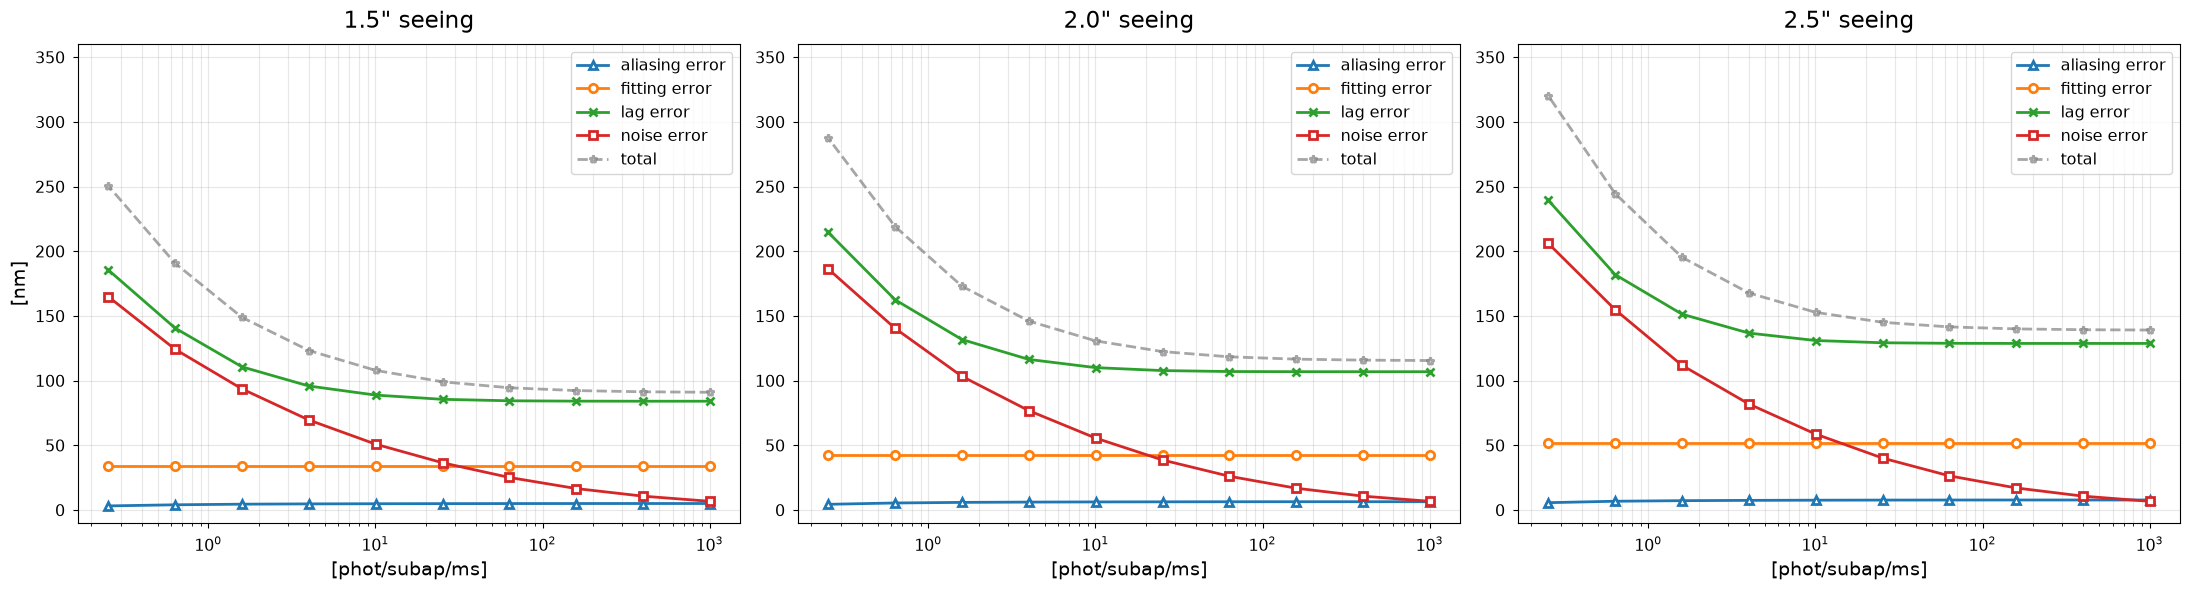

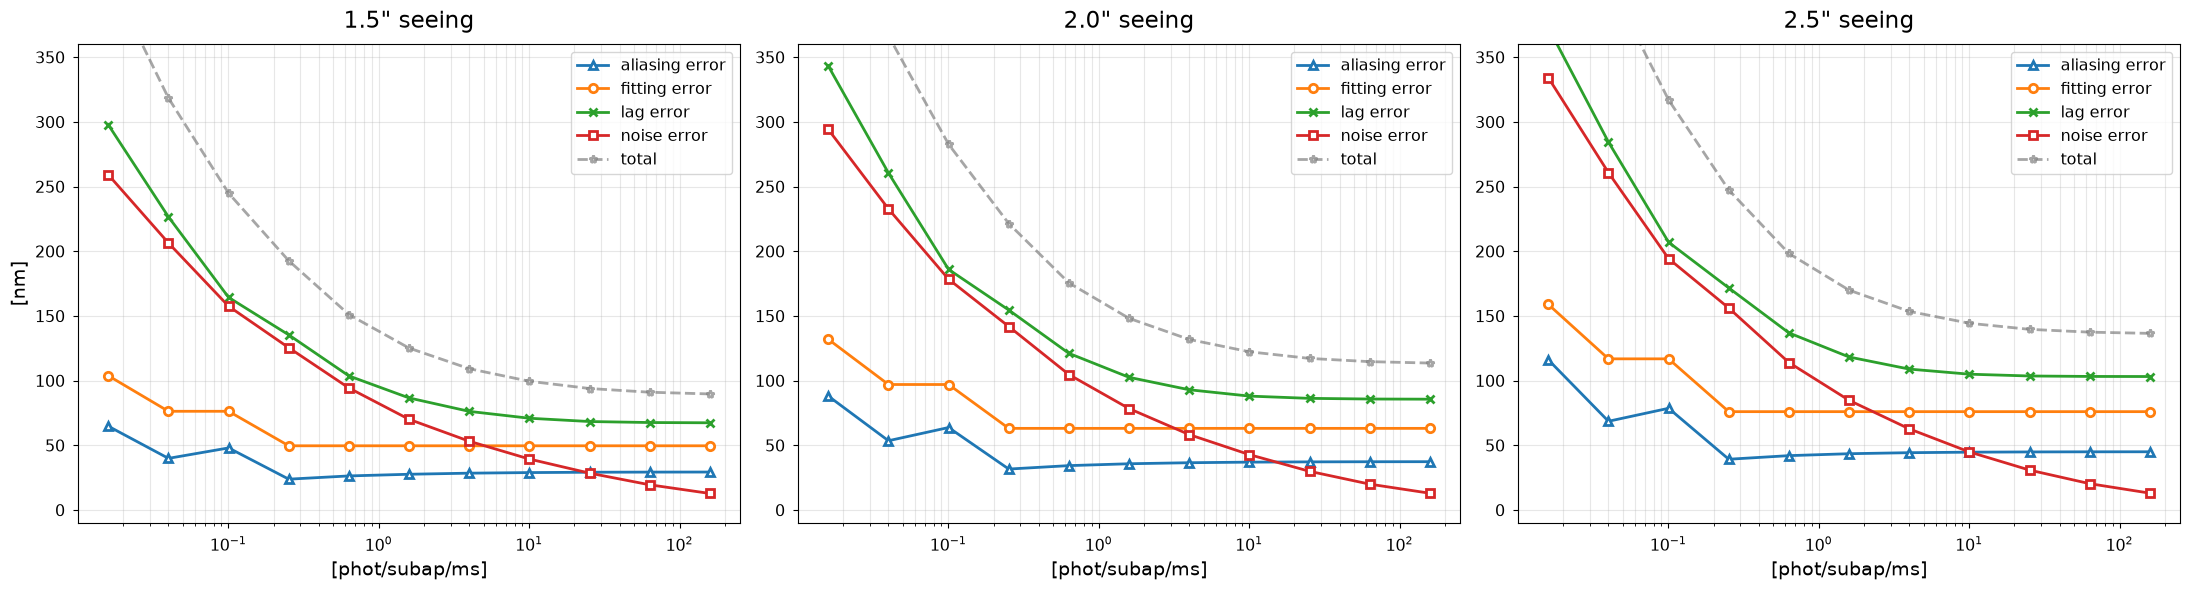

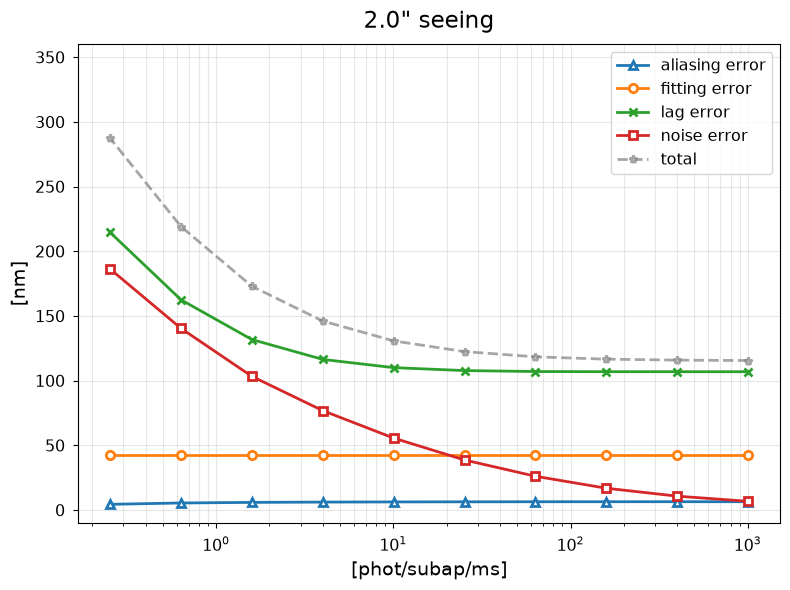

In [ ]:
def plot_error_vs_magnitude(df, seeings=[1.5,2.0,2.5], mag_col='magnitude', error_suffix='_error',
                             figsize=(22, 6), ymax = 360, palette=plt.cm.tab10.colors,
                             overall_title=None, min_mag=0, max_mag=10, fontsize_scale=1.4):

    markers=['^','o','x','s']

    error_cols = [col for col in df.columns if col.endswith(error_suffix) and not col.startswith('best_')]
    if len(error_cols) == 0:
        raise ValueError(f'No error columns found ending with "{error_suffix}"')
    error_cols = sorted(error_cols)

    # Prepare containers for returned matrices (list of lists)
    vv_rows = []
    toterr_rows = []

    fig, axes = plt.subplots(1, len(seeings), figsize=figsize, squeeze=False)
    max_cols = 0
    for idx, seeing in enumerate(seeings):
        ax = axes[0, idx]
        # select only rows within the requested magnitude interval
        subdf_all = df[df['seeing'] == seeing]
        subdf = subdf_all[(subdf_all[mag_col] >= min_mag) & (subdf_all[mag_col] <= max_mag)].sort_values(mag_col)

        # If multiple rows per magnitude (e.g., due to 'bin' column), keep only the row with lowest total error
        if len(error_cols) > 0 and len(subdf) > 0:
            def calc_total_error(row):
                return np.sqrt(np.sum(row[error_cols]**2))
            subdf['_total_error'] = subdf.apply(calc_total_error, axis=1)
            subdf = subdf.loc[subdf.groupby(mag_col)['_total_error'].idxmin()]
            subdf = subdf.drop(columns=['_total_error'])
            subdf = subdf.sort_values(mag_col)

        if subdf.empty:
            # nothing to plot for this seeing; record empty rows
            vv_rows.append([])
            toterr_rows.append([])
            continue

        # Index by magnitude for easy lookup
        subdf_indexed = subdf.set_index(mag_col)

        # Compute total error per magnitude from the chosen (best) rows
        total_error_series = np.sqrt(np.sum(subdf_indexed[error_cols]**2, axis=1))

        # Extract best_flux, frequency, and bin values from the best row per magnitude
        best_flux_series = subdf_indexed.get('best_flux', pd.Series(np.nan, index=subdf_indexed.index))
        freq_series = subdf_indexed.get('best_frequency', pd.Series(np.nan, index=subdf_indexed.index))
        if 'bin' in subdf.columns:
            bin_series = subdf_indexed['bin']
        else:
            bin_series = pd.Series(1, index=subdf_indexed.index)

        # Get magnitude ticks (for indexing)
        mag_ticks = sorted(subdf[mag_col].unique())

        # Build vv and total-error lists aligned with mag_ticks
        vv_list = []
        tot_list = []
        for m in mag_ticks:
            # best_flux or frequency may be missing -> produce nan
            bf = best_flux_series.loc[m] if m in best_flux_series.index else np.nan
            fv = freq_series.loc[m] if m in freq_series.index else np.nan
            bv = bin_series.loc[m] if m in bin_series.index else 1
            if pd.isna(bf) or pd.isna(fv):
                vv = np.nan
            else:
                vv = bf * fv / 1000.0 / (bv**2)
            vv_list.append(vv)
            tot_list.append(total_error_series.loc[m] if m in total_error_series.index else np.nan)

        # Extract error values in order of mag_ticks
        error_values = {col: [subdf_indexed.loc[m, col] if m in subdf_indexed.index else np.nan 
                              for m in mag_ticks] 
                        for col in error_cols}

        # Plot each error component using vv values as x-axis
        for color, col, marker in zip(palette, error_cols, markers):
            ax.plot(
                vv_list,
                error_values[col],
                marker=marker,
                linestyle='-',
                linewidth=2,
                markersize=6,
                markerfacecolor='white', 
                markeredgewidth=2, 
                color=color,
                label=col.replace('_', ' ')
            )

        # Plot total error using vv values as x-axis
        ax.plot(
            vv_list,
            tot_list,
            marker='*',
            linestyle='--',
            linewidth=2,
            markersize=6,
            markerfacecolor='white', 
            markeredgewidth=2,
            alpha=0.7,
            color='gray',
            label='total',
        )

        # title and labels
        ax.set_title(f'{seeing:1.1f}" seeing', pad=12, fontsize=12*fontsize_scale)
        ax.set_xlabel('[phot/subap/ms]', fontsize=10*fontsize_scale)
        if idx == 0:
            ax.set_ylabel('[nm]', fontsize=10*fontsize_scale)

        # Set xticks using vv_list
        ax.set_xticks(vv_list)
        
        # Format labels for plotting (show every Nth to avoid overlap)
        n = len(vv_list)
        step = 1 if n <= 6 else 2
        labels = [ (f"{v:1.1e}" if (i % step == 0) and (not pd.isna(v)) else '') for i, v in enumerate(vv_list) ]
        ax.set_xticklabels(labels)
        ax.tick_params(axis='both', which='major', labelsize=8*fontsize_scale, pad=6)

        ax.set_xscale('log')

        ax.grid(True, which='both', alpha=0.3)
        ax.set_ylim([-10,ymax])
        ax.legend(fontsize=8*fontsize_scale, loc='best')

        # store row data
        vv_rows.append(vv_list)
        toterr_rows.append(tot_list)
        if len(vv_list) > max_cols:
            max_cols = len(vv_list)

    # Pad rows with NaN so we can return rectangular 2D arrays
    vv_matrix = np.full((len(seeings), max_cols), np.nan, dtype=float)
    toterr_matrix = np.full((len(seeings), max_cols), np.nan, dtype=float)
    for i, (vr, tr) in enumerate(zip(vv_rows, toterr_rows)):
        for j, v in enumerate(vr):
            vv_matrix[i, j] = v
        for j, t in enumerate(tr):
            toterr_matrix[i, j] = t

    # Keep existing figure display behavior but return computed matrices instead of fig, axes
    if overall_title is not None:
        fig.suptitle(overall_title, y=0.98, fontsize=14*fontsize_scale)
        fig.tight_layout(rect=[0, 0, 1, 0.93])
    else:
        fig.tight_layout()

    return vv_matrix, toterr_matrix

# Example usage:
dataframe = pd.read_csv('/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay1.50ms_bin1.csv')
vv,tot=plot_error_vs_magnitude(dataframe, min_mag=0, max_mag=9)
vvc,totc=plot_error_vs_magnitude(combined_df, min_mag=2, max_mag=12)

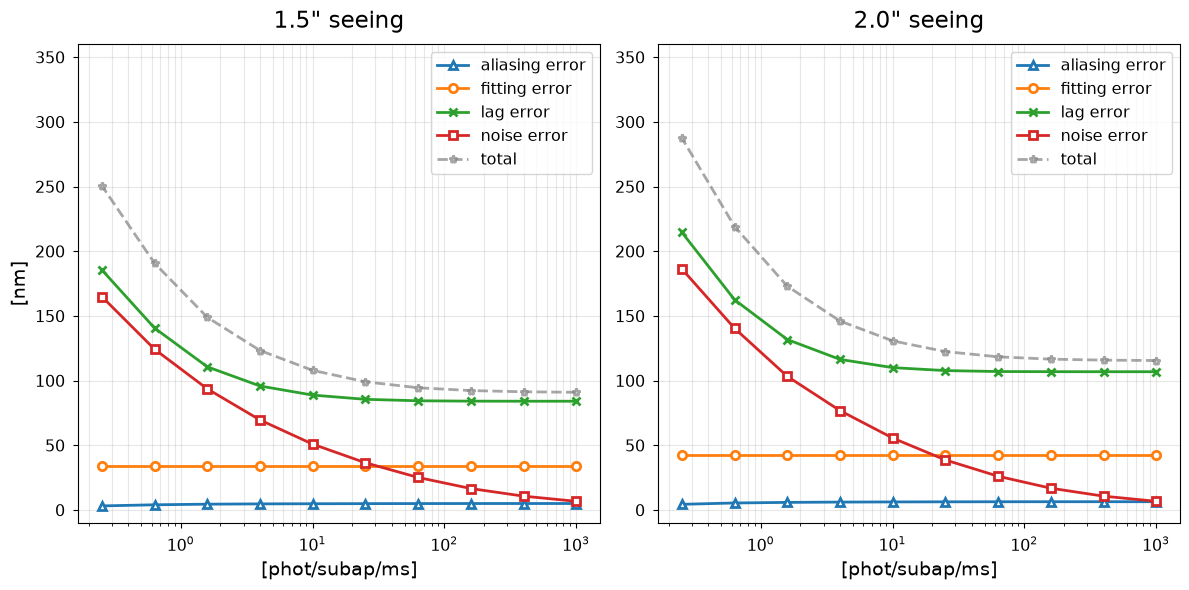

In [20]:

vv,tot=plot_error_vs_magnitude(dataframe, min_mag=0, max_mag=9,seeings=[1.5,2.0],figsize=(12,6))

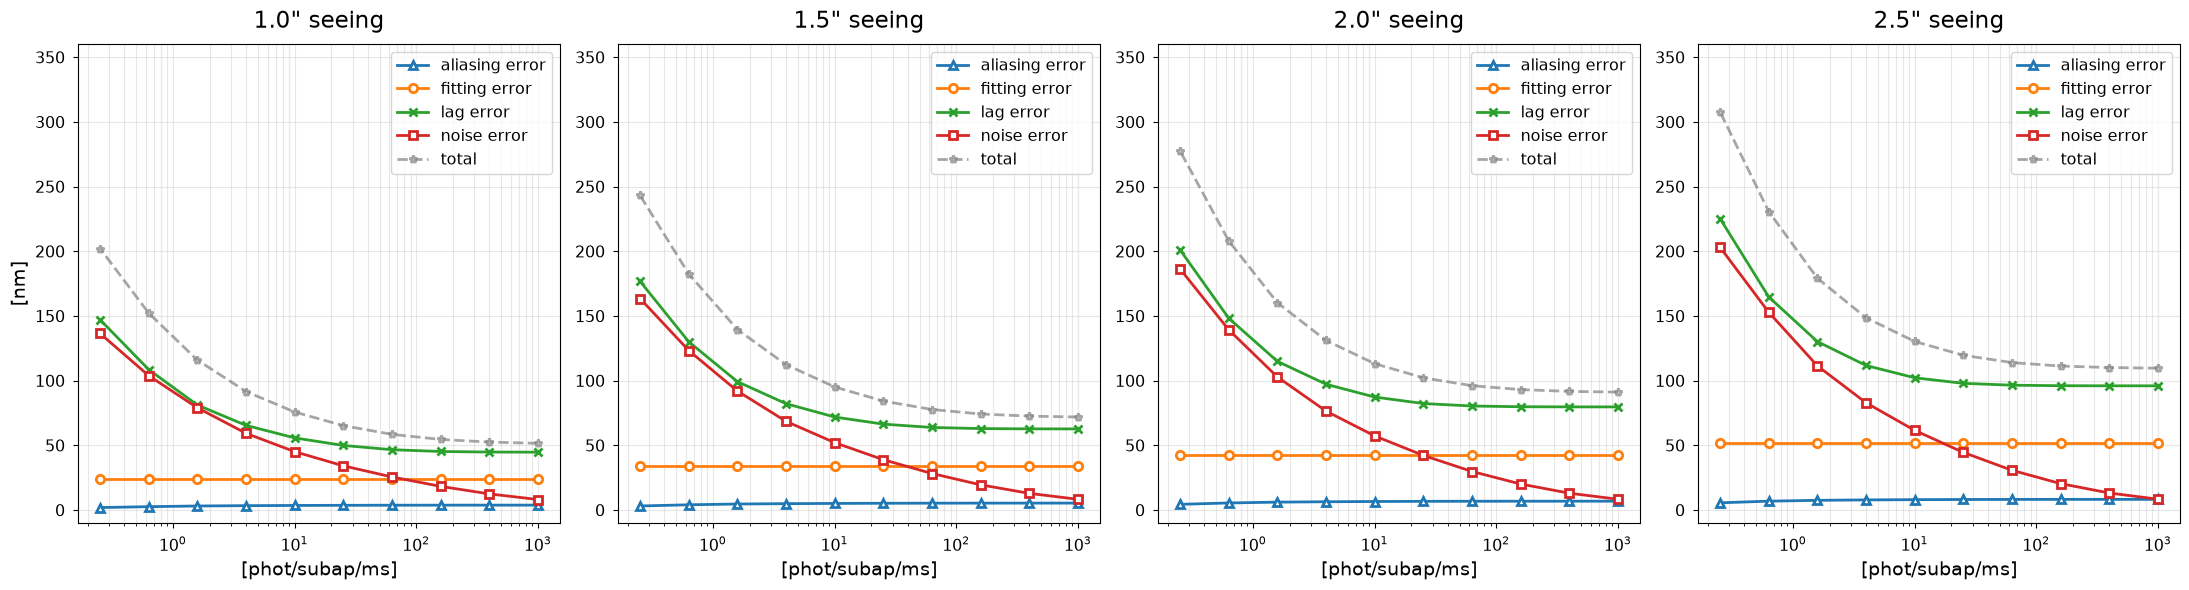

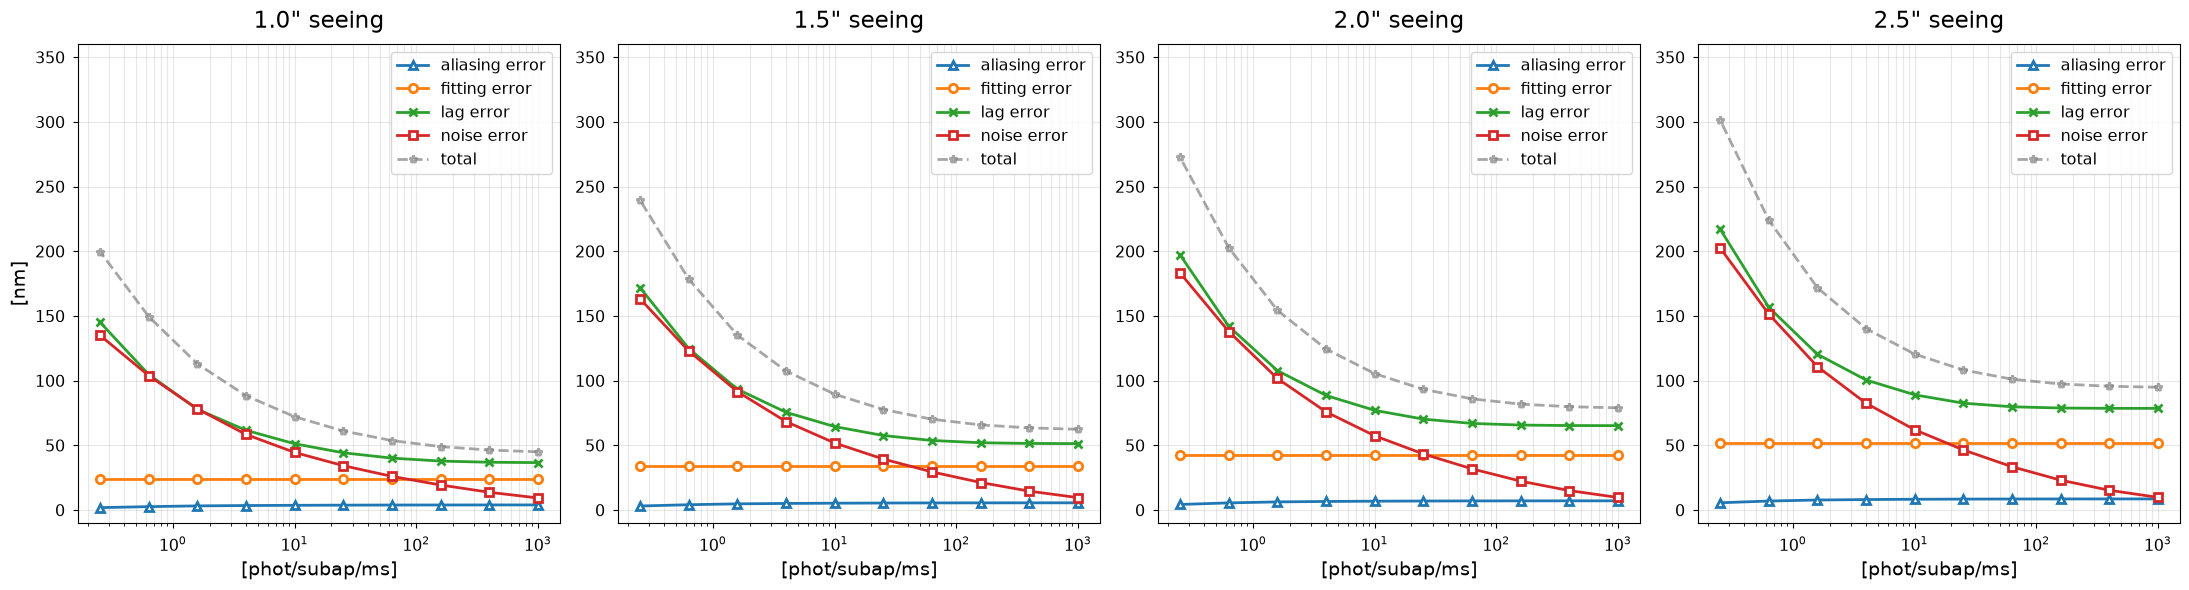

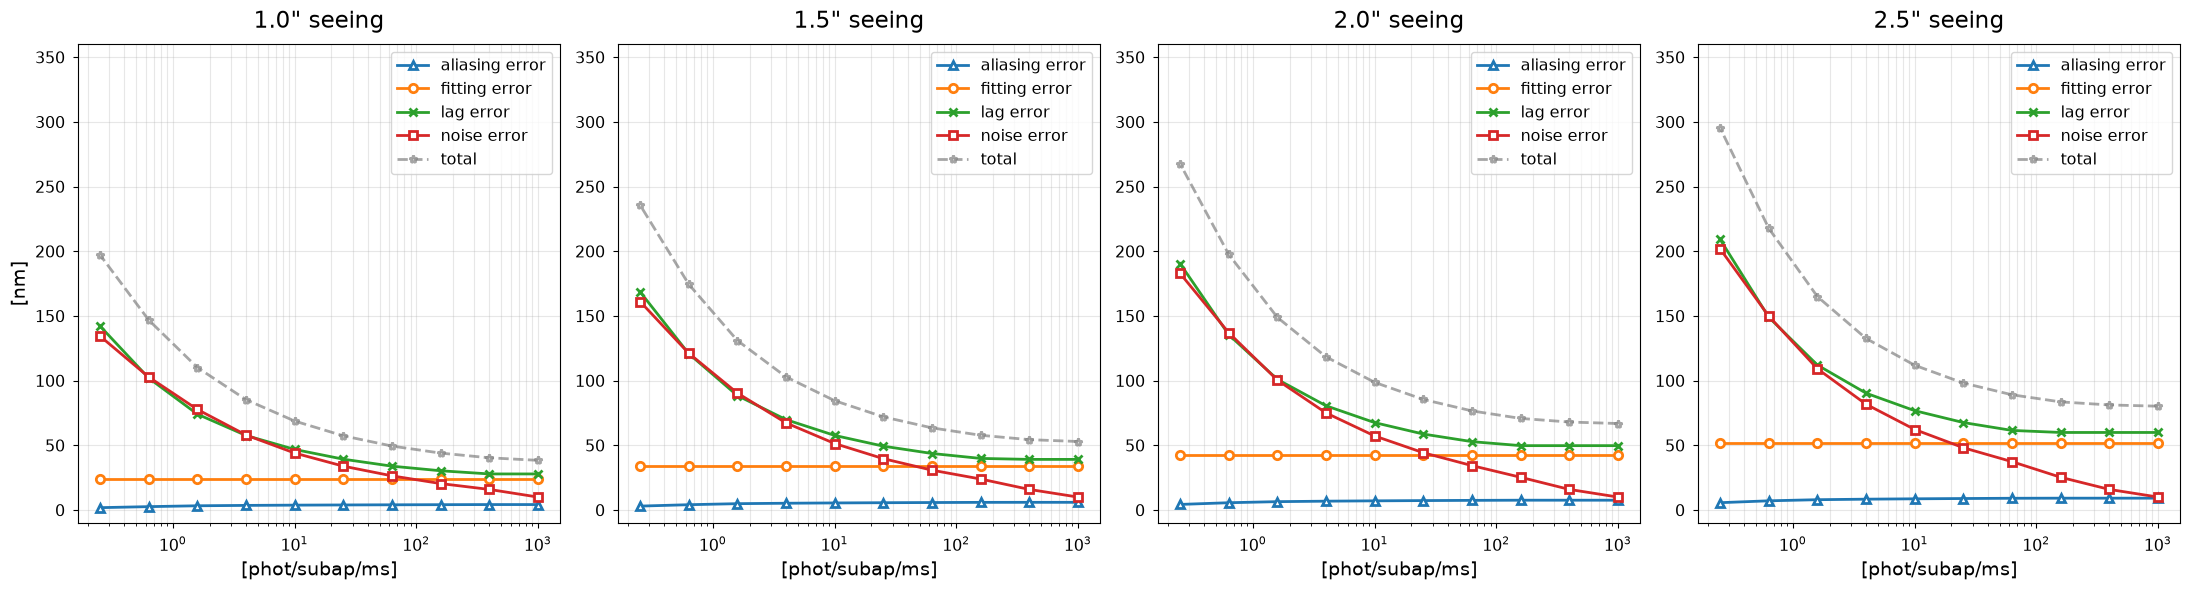

In [4]:

dataframe2 = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay1.00ms_bin1.csv')
vv2,tot2=plot_error_vs_magnitude(dataframe2, min_mag=0, max_mag=9)
dataframe3 = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay0.75ms_bin1.csv')
vv3,tot3=plot_error_vs_magnitude(dataframe3, min_mag=0, max_mag=9)
dataframe4 = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay0.50ms_bin1.csv')
vv4,tot4=plot_error_vs_magnitude(dataframe4, min_mag=0, max_mag=9)

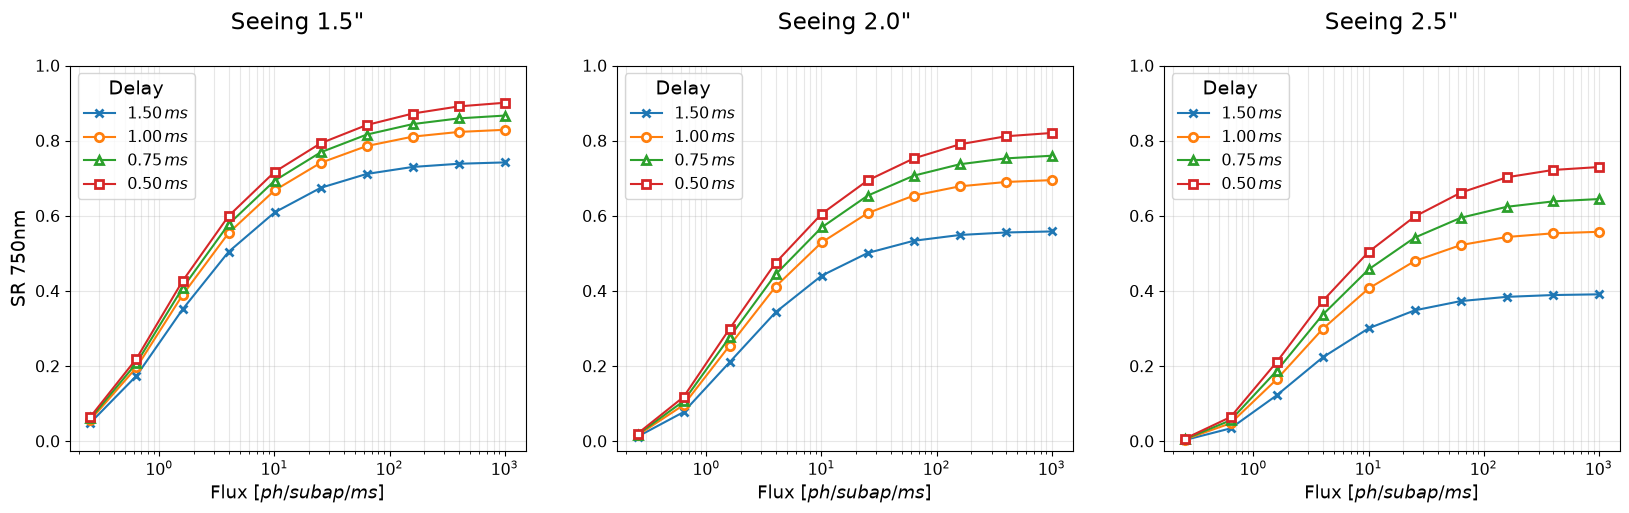

In [5]:
sr = lambda err,wvl: np.exp(-(err/wvl*2*np.pi)**2)
seeings = np.array([1.5,2.0,2.5])

plt.figure(figsize=(20,5))
for idx in range(3):
    plt.subplot(1,3,idx+1)
    plt.semilogx(vv[idx],sr(tot[idx],750), marker='x',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label=r'$1.50\,ms$')
    plt.semilogx(vv[idx],sr(tot2[idx],750), marker='o',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label=r'$1.00\,ms$')
    plt.semilogx(vv[idx],sr(tot3[idx],750), marker='^',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label=r'$0.75\,ms$')
    plt.semilogx(vv[idx],sr(tot4[idx],750), marker='s',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label=r'$0.50\,ms$')
    plt.legend(title='Delay', loc='upper left', fontsize=8*1.4, title_fontsize=10*1.4)
    plt.xlabel(r'Flux $[ph/subap/ms]$',fontsize=13)
    plt.xticks(fontsize=8*1.4)
    plt.yticks(fontsize=8*1.4)
    if idx == 0:
        plt.ylabel('SR 750nm',fontsize=10*1.4)
    plt.grid(which='both',alpha=0.3)
    plt.ylim([-0.025,1])
    plt.title(f'Seeing {seeings[idx]:1.1f}"\n',fontsize=12*1.4)


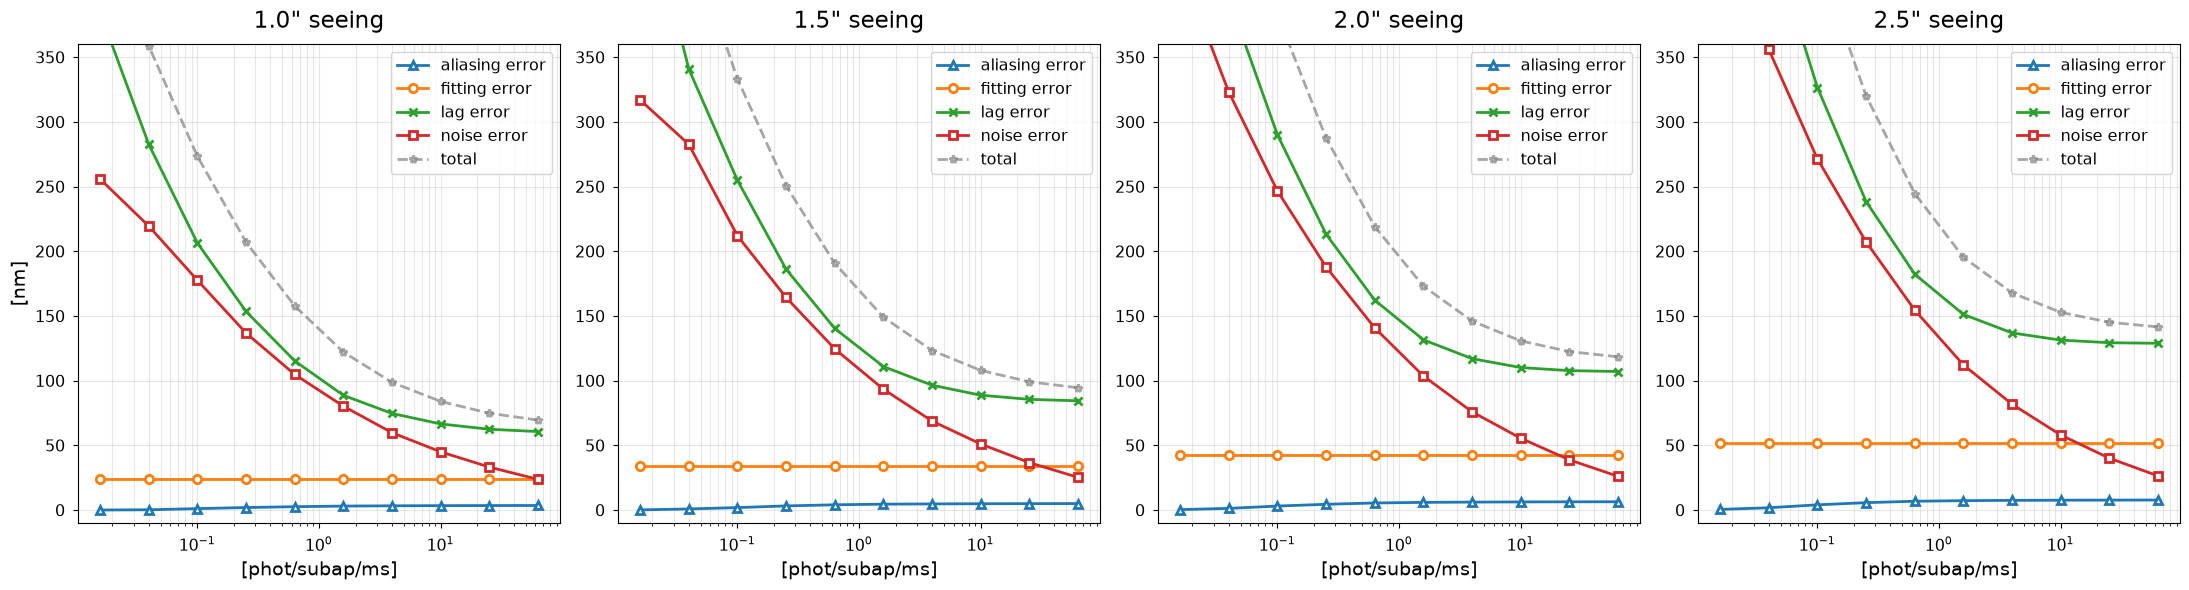

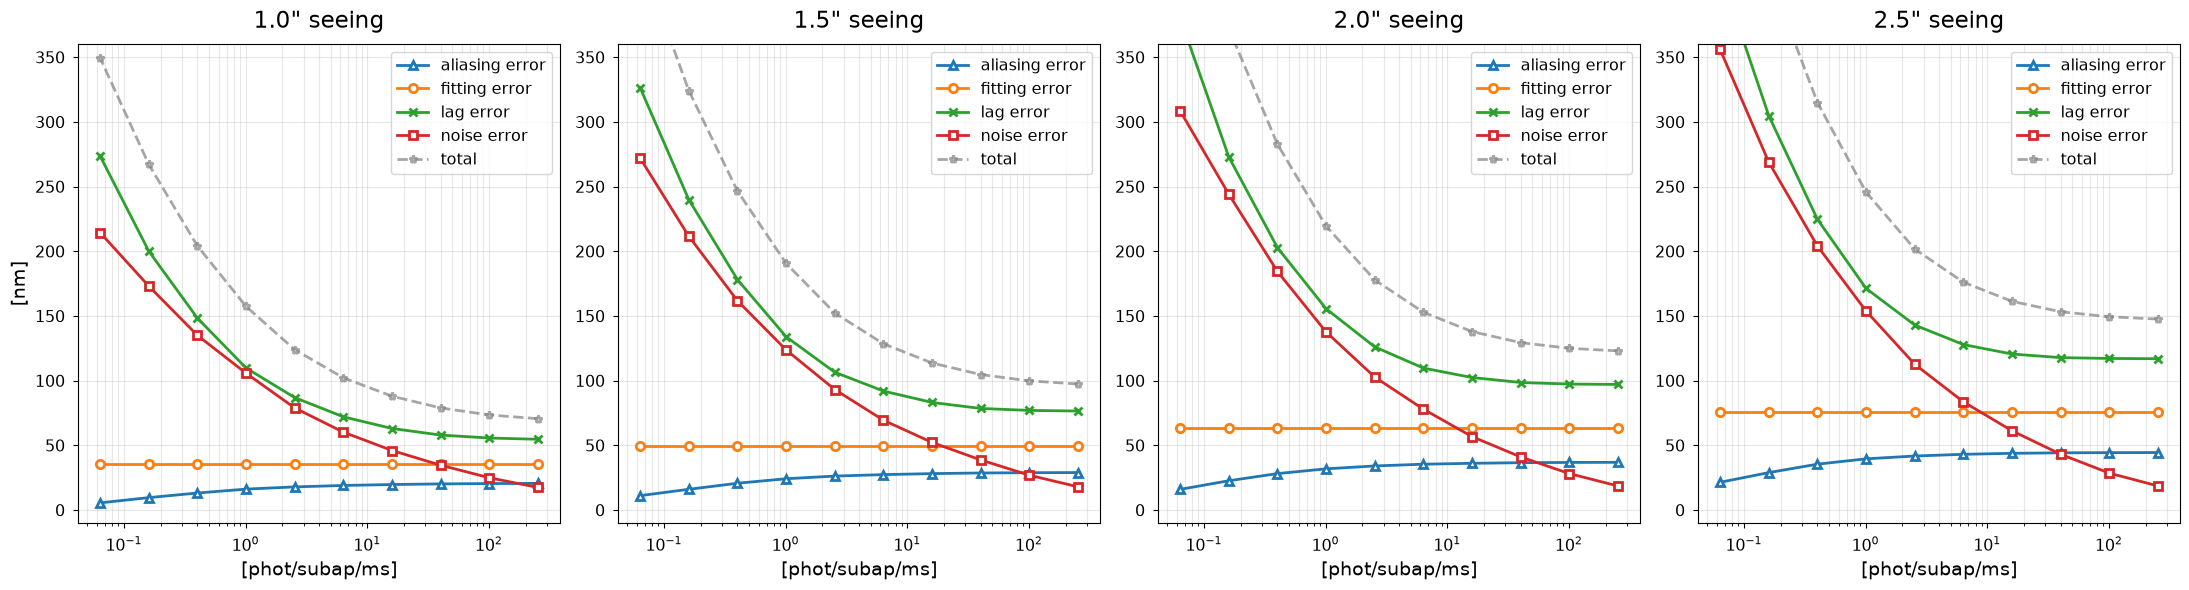

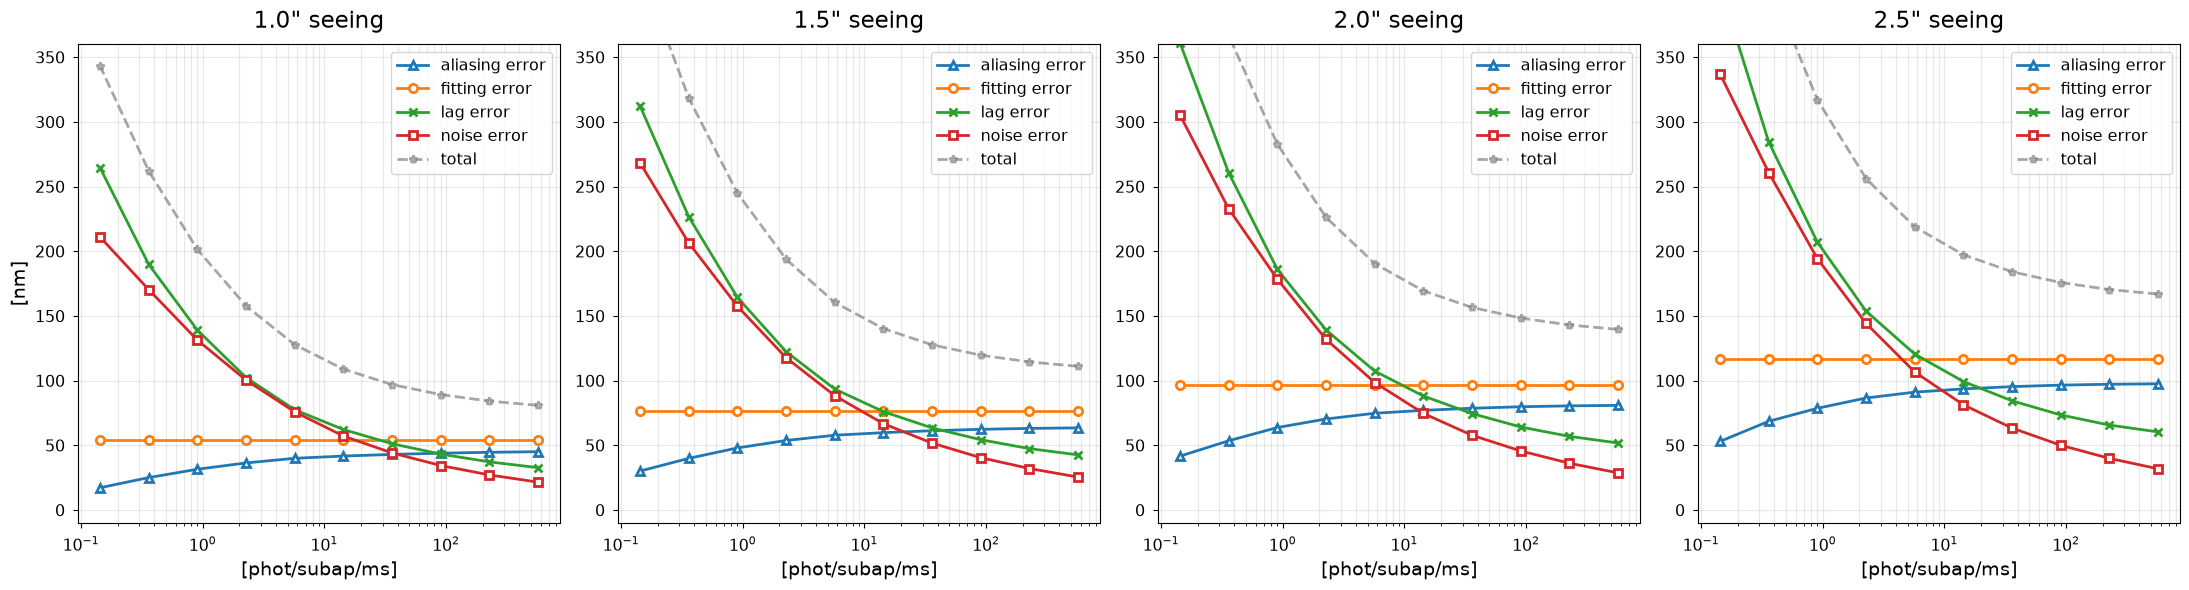

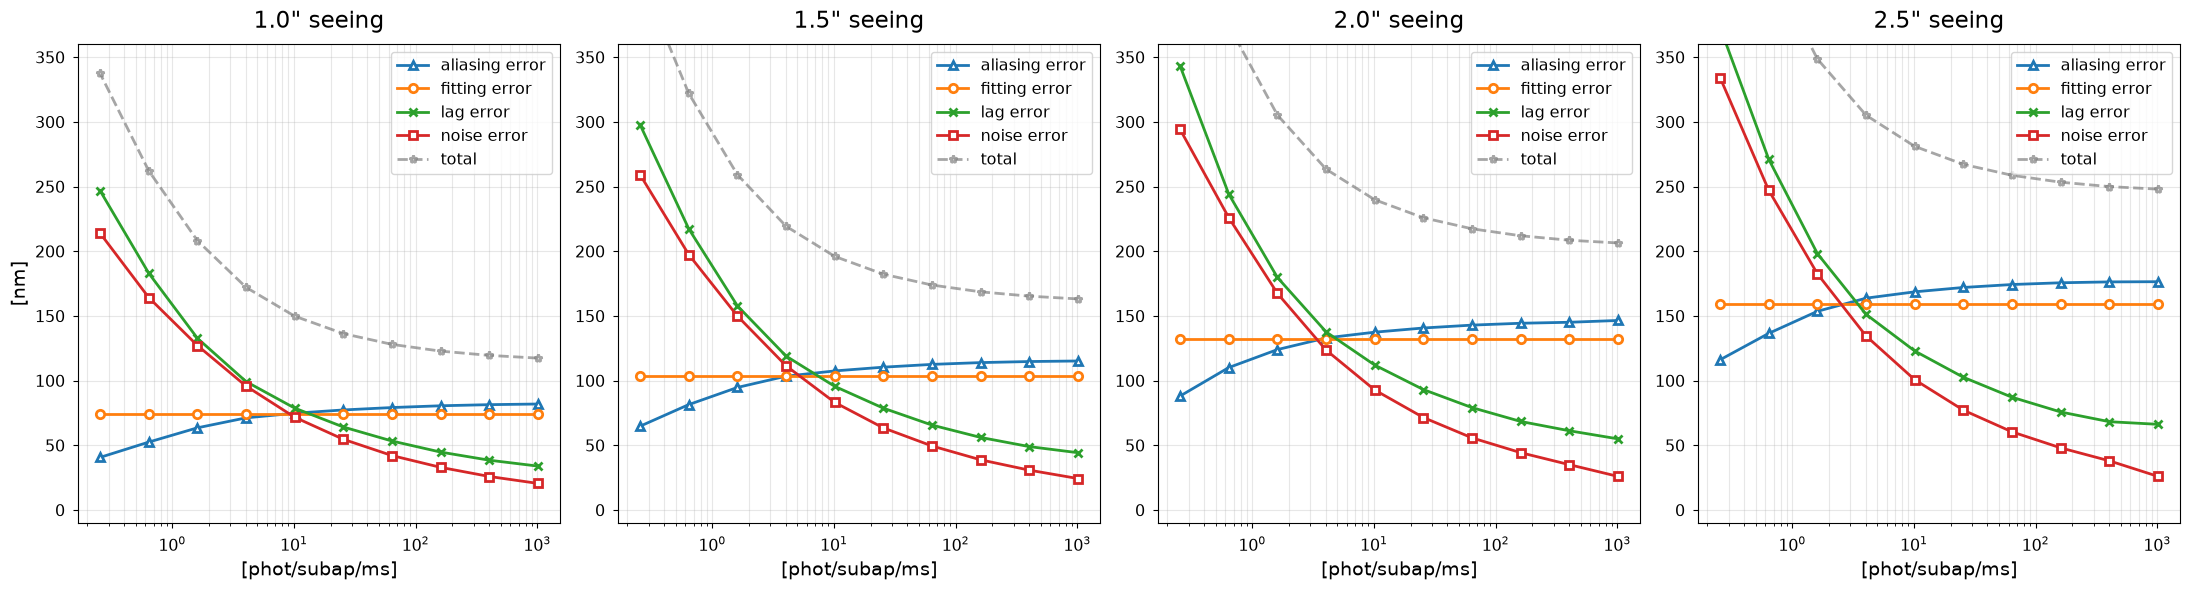

In [6]:

dataframe = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay1.50ms_bin1.csv')
vv,tot=plot_error_vs_magnitude(dataframe, min_mag=3, max_mag=12)
dataframe2 = pd.read_csv('/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay1.50ms_bin2.csv')
vv2,tot2=plot_error_vs_magnitude(dataframe2, min_mag=3, max_mag=12)
dataframe3 = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay1.50ms_bin3.csv')
vv3,tot3=plot_error_vs_magnitude(dataframe3, min_mag=3, max_mag=12)
dataframe4 = pd.read_csv('/raid1/mmenessini/results/EKARUS/ebv2_csv/eb_ekarus_rMod5.0_delay1.50ms_bin4.csv')
vv4,tot4=plot_error_vs_magnitude(dataframe4, min_mag=3, max_mag=12)

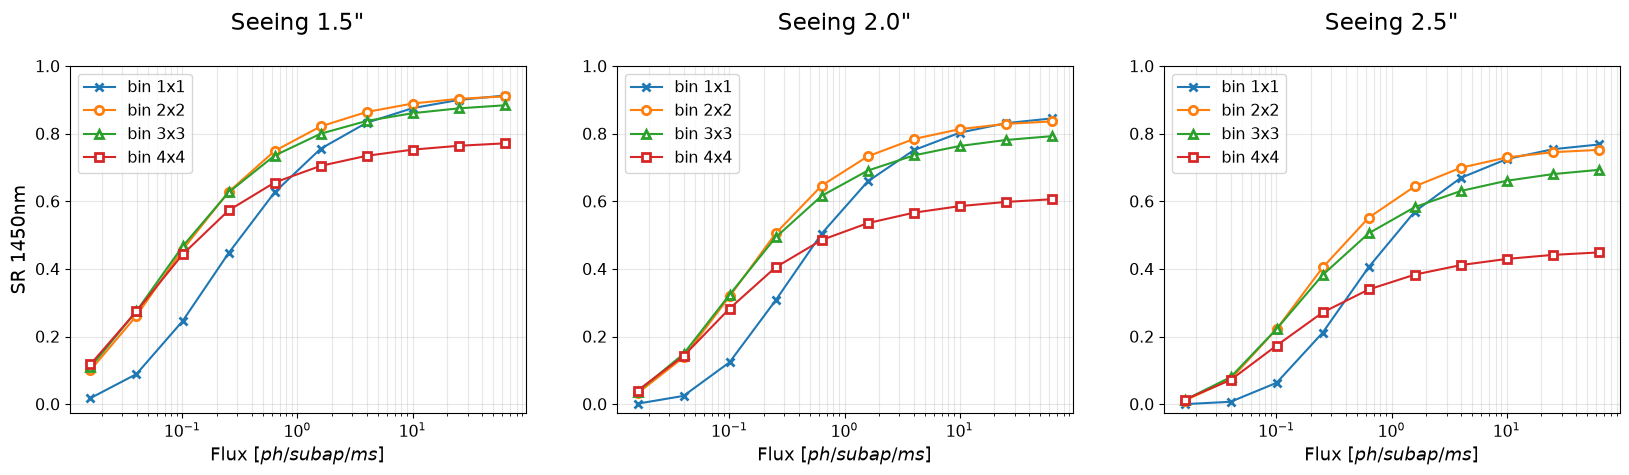

In [7]:
plt.figure(figsize=(20,4.5))
for idx in range(3):
    plt.subplot(1,3,idx+1)
    plt.semilogx(vv[idx],sr(tot[idx],1450), marker='x',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label='bin 1x1')
    plt.semilogx(vv[idx],sr(tot2[idx],1450), marker='o',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2,label='bin 2x2')
    plt.semilogx(vv[idx],sr(tot3[idx],1450), marker='^',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label='bin 3x3')
    plt.semilogx(vv[idx],sr(tot4[idx],1450), marker='s',linestyle='-',
                    markerfacecolor='white', 
                    markeredgewidth=2, label='bin 4x4')
    # plt.legend(loc='best')
    # plt.xlabel(r'Flux $[ph/subap/ms]$')
    # plt.ylabel('SR 1450nm')
    # plt.grid(which='both',alpha=0.3)
    # plt.ylim([-0.025,1])
    # plt.title(f'Seeing {seeings[idx]:1.1f}"')

    plt.legend(loc='upper left', fontsize=8*1.4, title_fontsize=10*1.4)
    plt.xlabel(r'Flux $[ph/subap/ms]$',fontsize=13)
    plt.xticks(fontsize=8*1.4)
    plt.yticks(fontsize=8*1.4)
    if idx == 0:
        plt.ylabel('SR 1450nm',fontsize=10*1.4)
    plt.grid(which='both',alpha=0.3)
    plt.ylim([-0.025,1])
    plt.title(f'Seeing {seeings[idx]:1.1f}"\n',fontsize=12*1.4)

In [8]:
df_base = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_baseline_rMod5.0_delay1.50ms_bin1.csv')
df_base_f1000 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay1.50ms_bin1.csv')
df_goal1 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_goal_rMod5.0_delay1.00ms_bin1.csv')
df_goal2 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_goal_rMod5.0_delay1.00ms_bin2.csv')
df_opt1 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_best_rMod5.0_delay0.50ms_bin1.csv')
df_opt2 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_best_rMod5.0_delay0.50ms_bin2.csv')
df_opt3 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_best_rMod5.0_delay0.50ms_bin3.csv')
df_opt4 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_best_rMod5.0_delay0.50ms_bin4.csv')
df_opt1_f1000 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay0.50ms_bin1.csv')
df_opt2_f1000 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay0.50ms_bin2.csv')
df_opt3_f1000 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay0.50ms_bin3.csv')
df_opt4_f1000 = pd.read_csv(f'/raid1/mmenessini/results/EKARUS/eb_csv/eb_ekarus_rMod5.0_delay0.50ms_bin4.csv')

dfs = [df_goal1,df_goal2]
param_values = [1,2]
df_goal = pd.concat(
    [df.assign(bin=param) for df, param in zip(dfs, param_values)],
    ignore_index=True,
)

dfs = [df_opt1,df_opt2,df_opt3,df_opt4]
param_values = [1,2,3,4]
df_opt = pd.concat(
    [df.assign(bin=param) for df, param in zip(dfs, param_values)],
    ignore_index=True,
)

dfs = [df_opt1_f1000,df_opt2_f1000,df_opt3_f1000,df_opt4_f1000]
param_values = [1,2,3,4]
df_opt_f1000 = pd.concat(
    [df.assign(bin=param) for df, param in zip(dfs, param_values)],
    ignore_index=True,
)

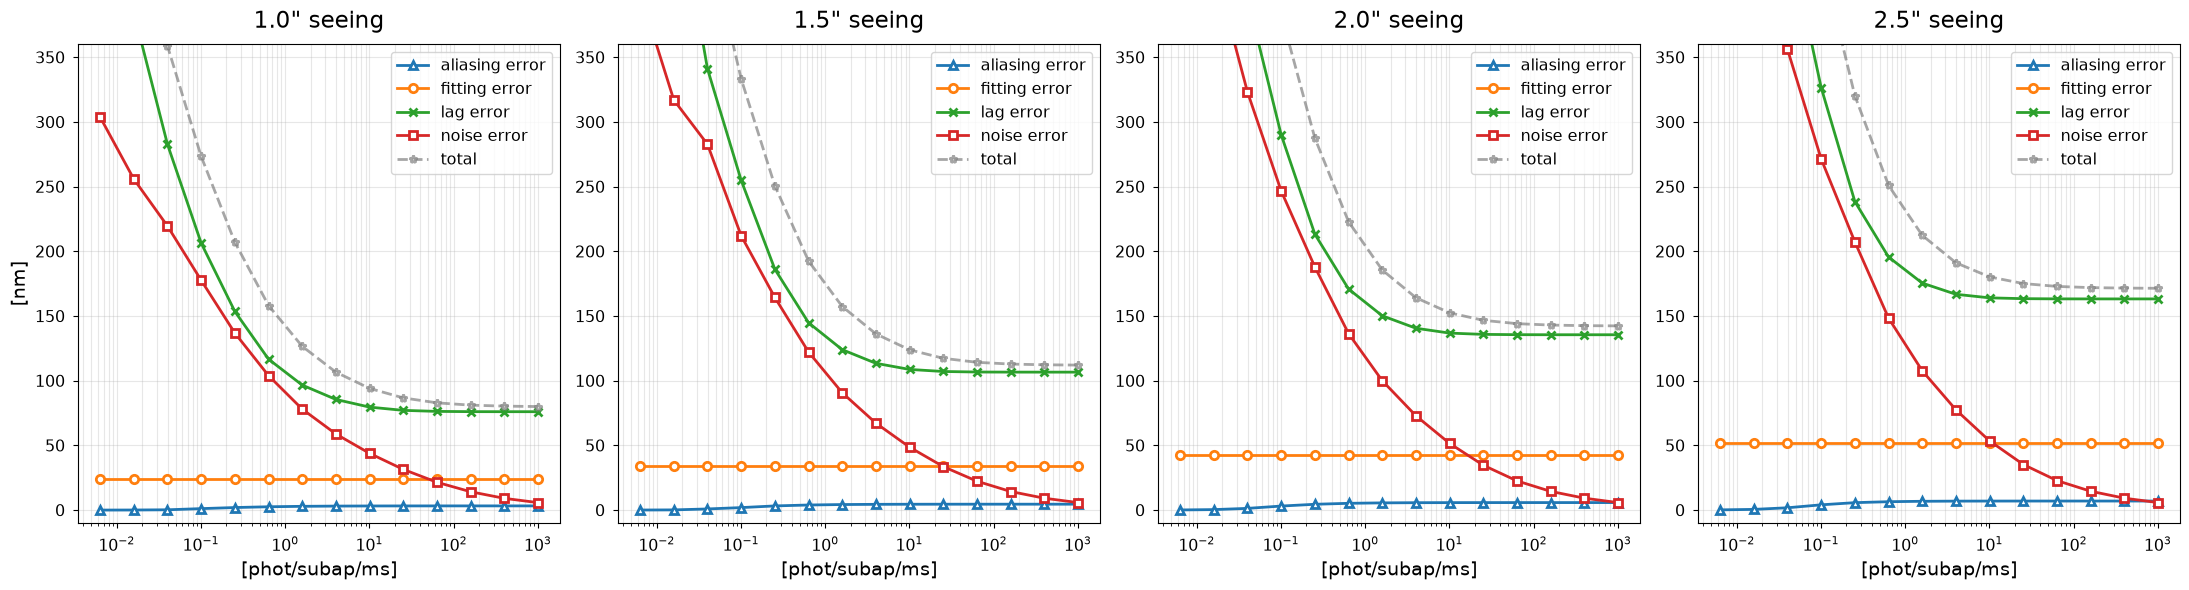

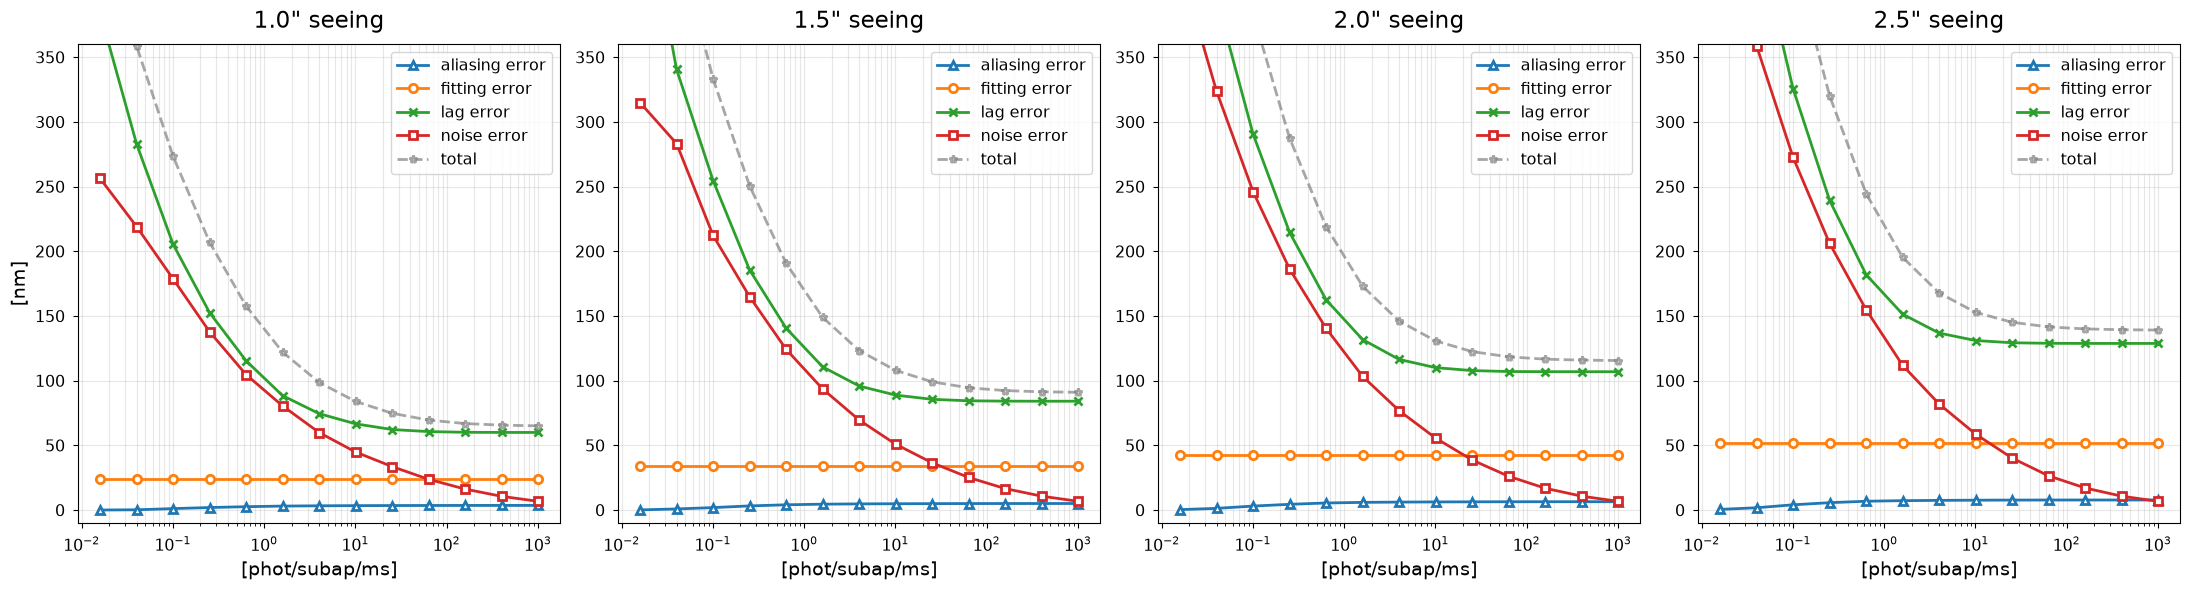

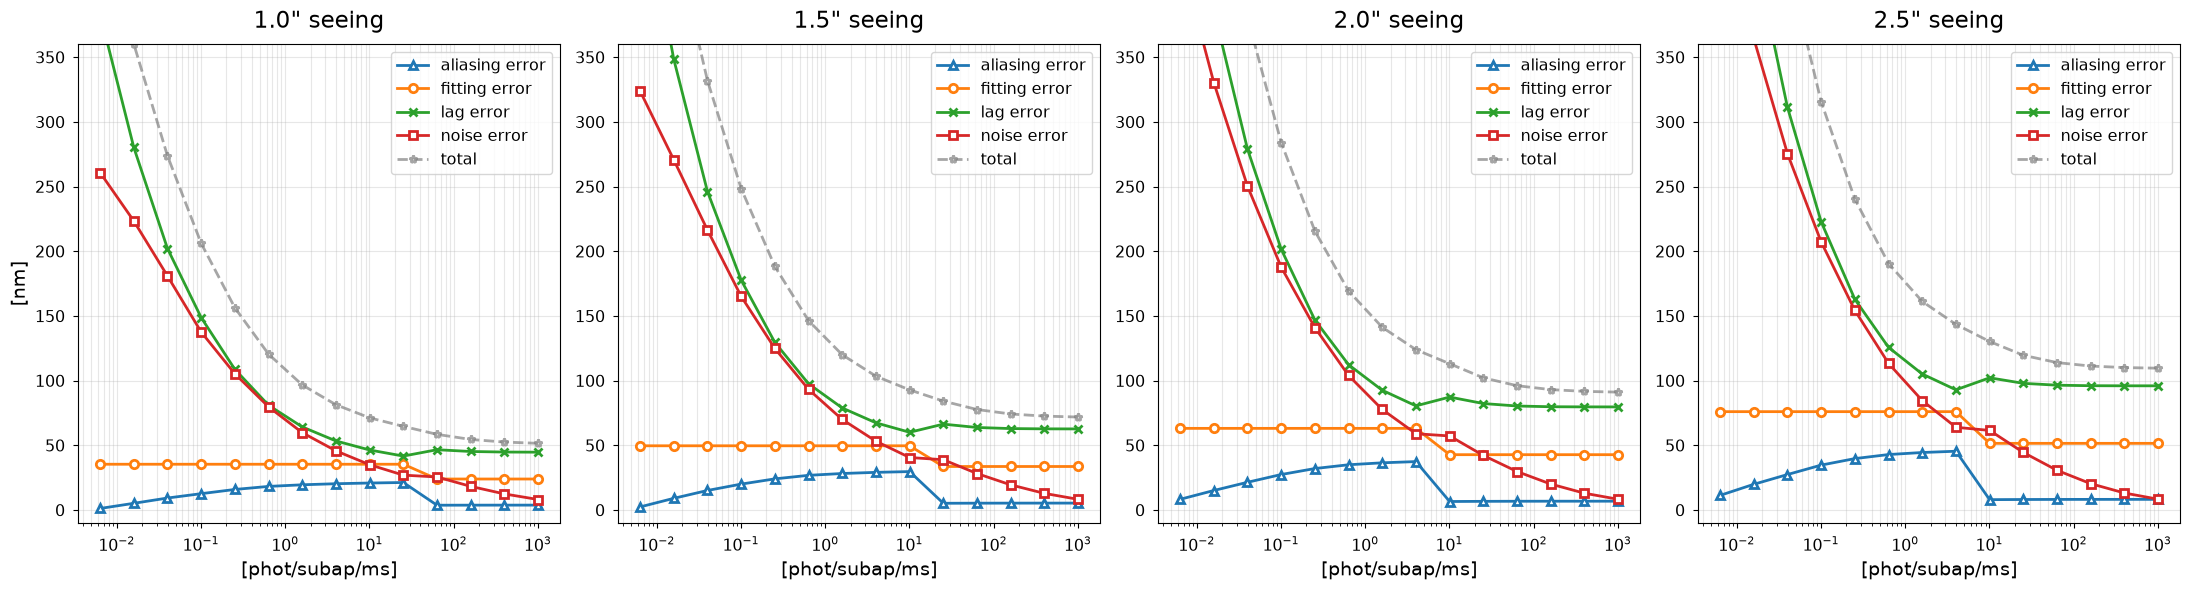

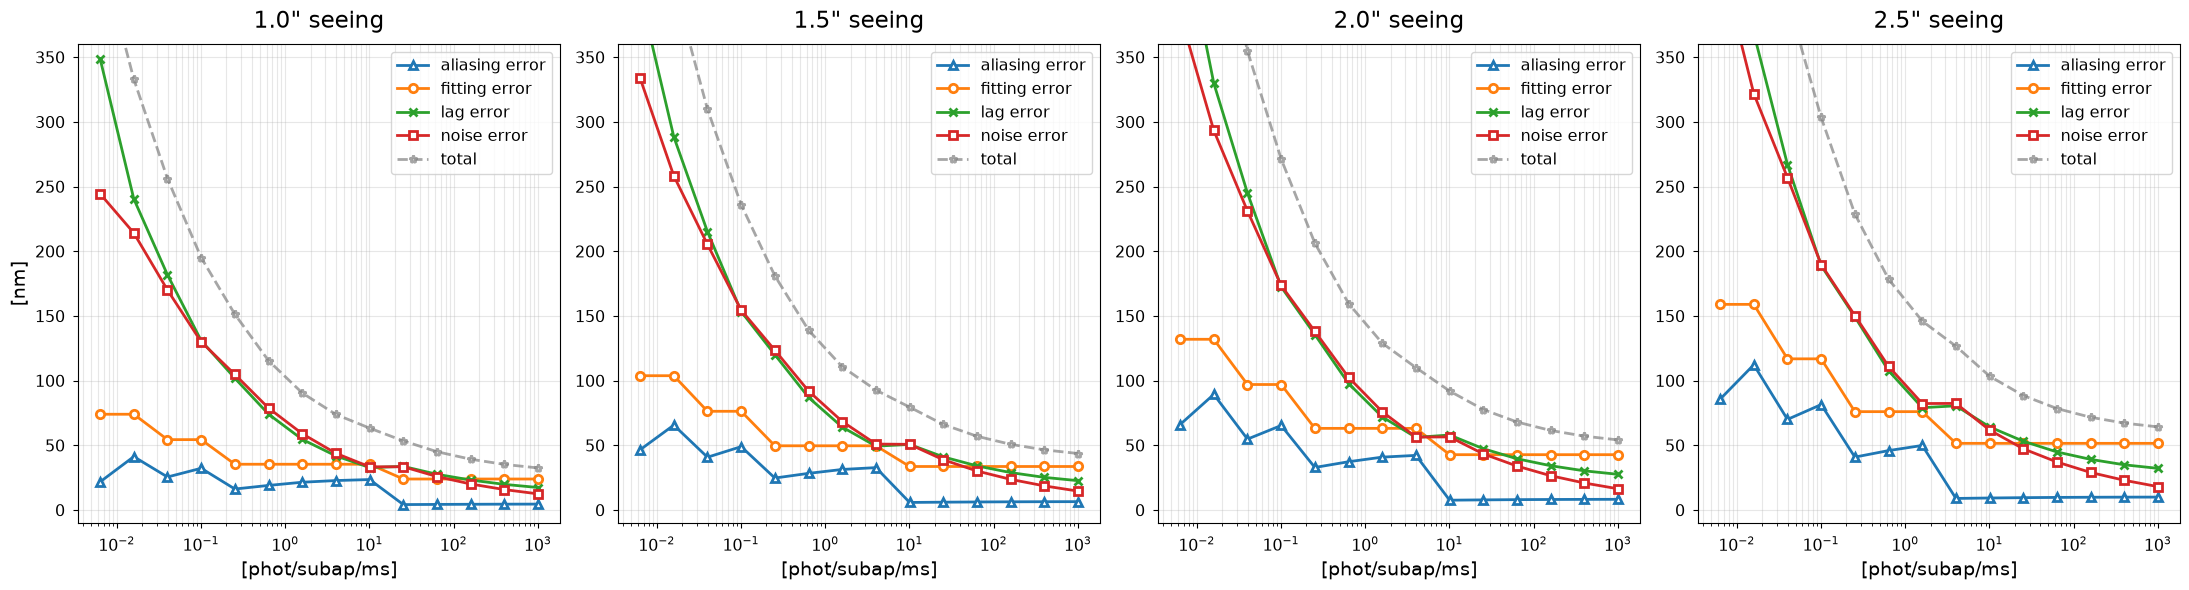

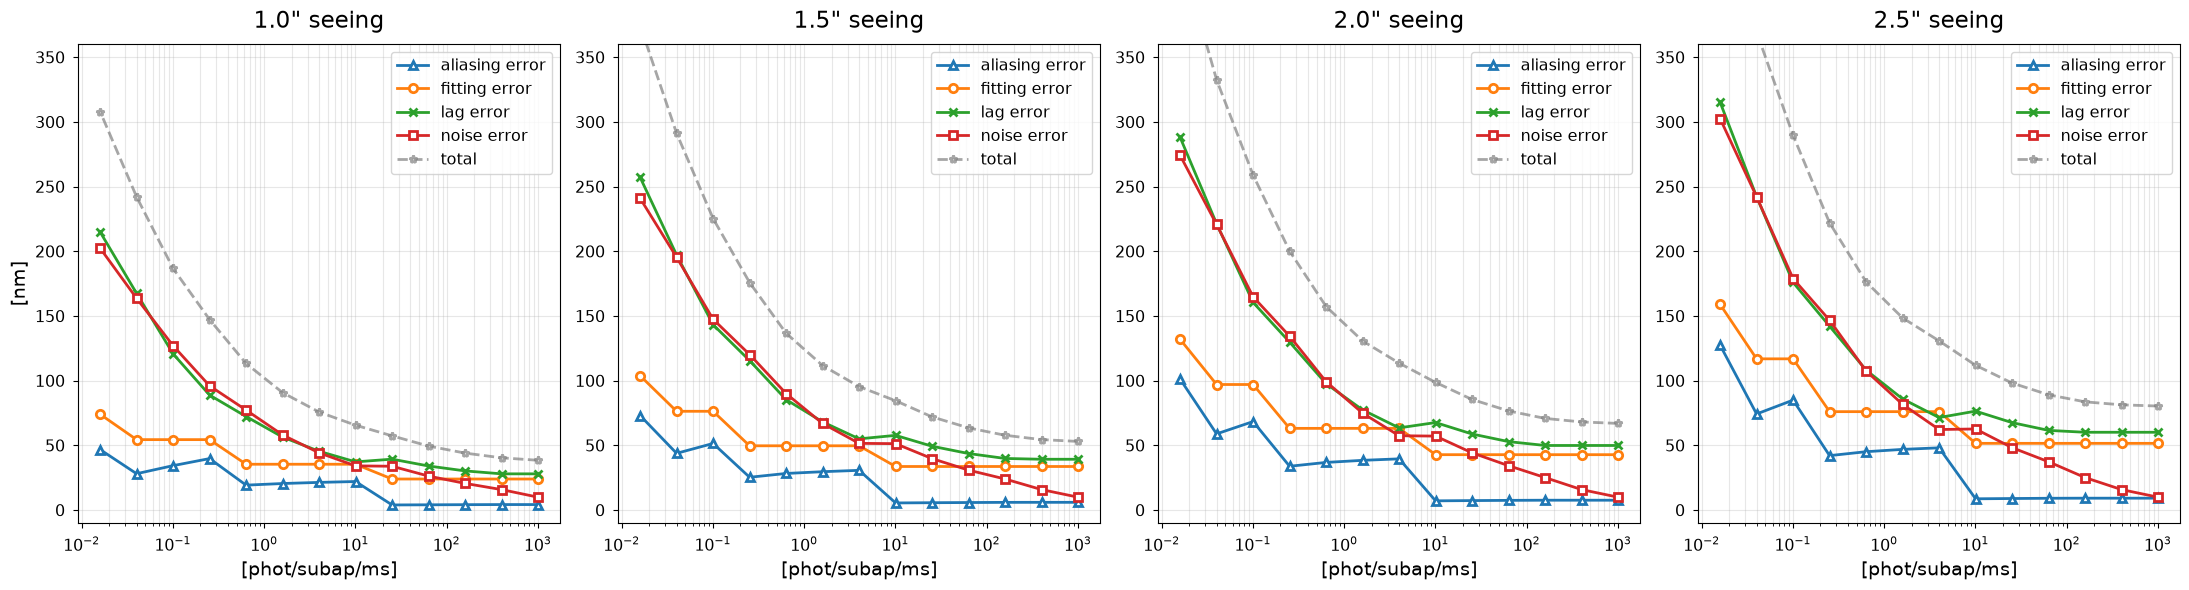

In [9]:
vv_base,tot_base=plot_error_vs_magnitude(df_base, min_mag=0, max_mag=13)
vv_base_f1000,tot_base_f1000=plot_error_vs_magnitude(df_base_f1000, min_mag=0, max_mag=13)
vv_goal,tot_goal=plot_error_vs_magnitude(df_goal, min_mag=0, max_mag=13)
vv_best,tot_best=plot_error_vs_magnitude(df_opt, min_mag=0, max_mag=13)
vv_best_f1000,tot_best_f1000=plot_error_vs_magnitude(df_opt_f1000, min_mag=0, max_mag=13)

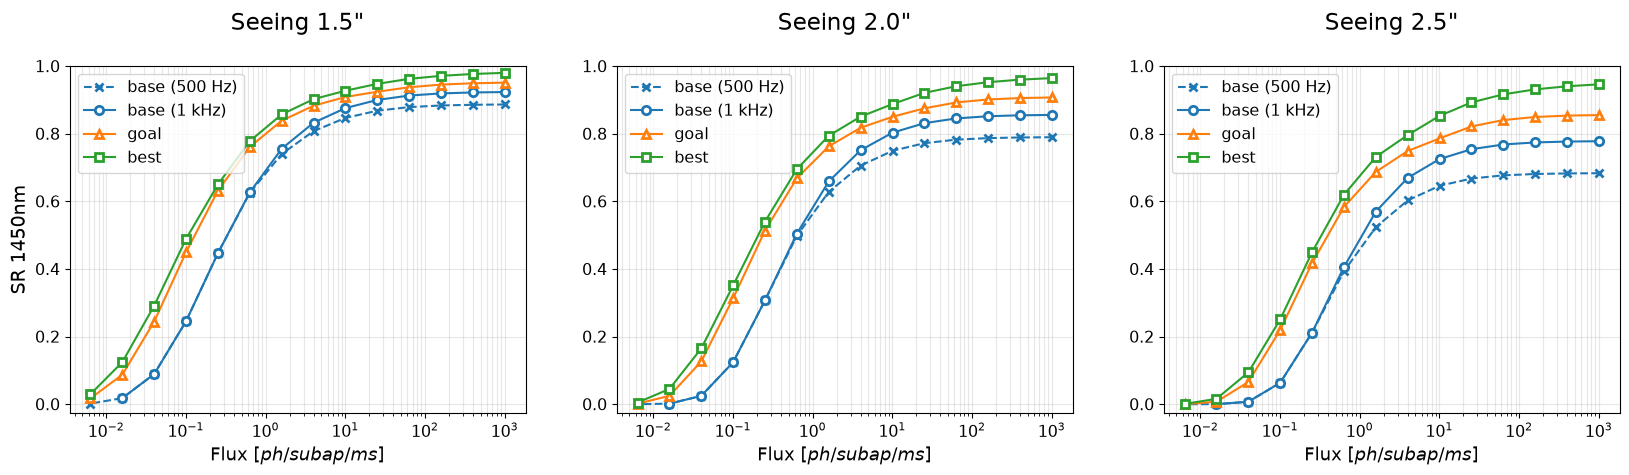

In [10]:
plt.figure(figsize=(20,4.5))
for idx in range(3):
    plt.subplot(1,3,idx+1)
    plt.semilogx(vv_base[idx],sr(tot_base[idx],1450), marker='x',linestyle='--',
                    markerfacecolor='white', c='C0',
                    markeredgewidth=2, label='base (500 Hz)')
    plt.semilogx(vv_base_f1000[idx],sr(tot_base_f1000[idx],1450), marker='o',linestyle='-',
                    markerfacecolor='white', c='C0',
                    markeredgewidth=2, label='base (1 kHz)')
    plt.semilogx(vv_goal[idx],sr(tot_goal[idx],1450), marker='^',linestyle='-',
                    markerfacecolor='white',  c='C1',
                    markeredgewidth=2,label='goal')
    plt.semilogx(vv_best[idx],sr(tot_best[idx],1450), marker='s',linestyle='-',
                    markerfacecolor='white',  c='C2',
                    markeredgewidth=2, label='best')
    # plt.semilogx(vv_best_f1000[idx],sr(tot_best_f1000[idx],1450), marker='o',linestyle='--',
    #                 markerfacecolor='white',  c='C2',
    #                 markeredgewidth=2, label='best')
    # plt.legend(loc='best')
    # plt.xlabel(r'Flux $[ph/subap/ms]$')
    # plt.ylabel('SR 1450nm')
    # plt.grid(which='both',alpha=0.3)
    # plt.ylim([-0.025,1])
    # plt.title(f'Seeing {seeings[idx]:1.1f}"')
    plt.legend(loc='upper left', fontsize=8*1.4, title_fontsize=10*1.4)
    plt.xlabel(r'Flux $[ph/subap/ms]$',fontsize=13)
    plt.xticks(fontsize=8*1.4)
    plt.yticks(fontsize=8*1.4)
    if idx == 0:
        plt.ylabel('SR 1450nm',fontsize=10*1.4)
    plt.grid(which='both',alpha=0.3)
    plt.ylim([-0.025,1])
    plt.title(f'Seeing {seeings[idx]:1.1f}"\n',fontsize=12*1.4)

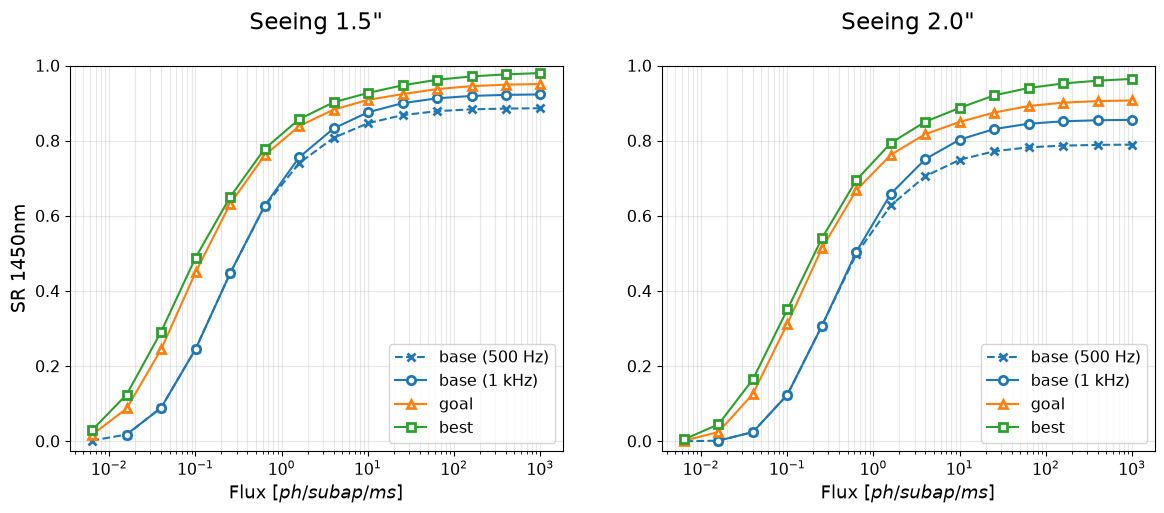

In [19]:
plt.figure(figsize=(14,5))
for idx in range(2):
    plt.subplot(1,2,idx+1)
    plt.semilogx(vv_base[idx],sr(tot_base[idx],1450), marker='x',linestyle='--',
                    markerfacecolor='white', c='C0',
                    markeredgewidth=2, label='base (500 Hz)')
    plt.semilogx(vv_base_f1000[idx],sr(tot_base_f1000[idx],1450), marker='o',linestyle='-',
                    markerfacecolor='white', c='C0',
                    markeredgewidth=2, label='base (1 kHz)')
    plt.semilogx(vv_goal[idx],sr(tot_goal[idx],1450), marker='^',linestyle='-',
                    markerfacecolor='white',  c='C1',
                    markeredgewidth=2,label='goal')
    plt.semilogx(vv_best[idx],sr(tot_best[idx],1450), marker='s',linestyle='-',
                    markerfacecolor='white',  c='C2',
                    markeredgewidth=2, label='best')
    # plt.semilogx(vv_best_f1000[idx],sr(tot_best_f1000[idx],1450), marker='o',linestyle='--',
    #                 markerfacecolor='white',  c='C2',
    #                 markeredgewidth=2, label='best')
    # plt.legend(loc='best')
    # plt.xlabel(r'Flux $[ph/subap/ms]$')
    # plt.ylabel('SR 1450nm')
    # plt.grid(which='both',alpha=0.3)
    # plt.ylim([-0.025,1])
    # plt.title(f'Seeing {seeings[idx]:1.1f}"')
    plt.legend(loc='lower right', fontsize=8*1.4, title_fontsize=10*1.4)
    plt.xlabel(r'Flux $[ph/subap/ms]$',fontsize=13)
    plt.xticks(fontsize=8*1.4)
    plt.yticks(fontsize=8*1.4)
    if idx == 0:
        plt.ylabel('SR 1450nm',fontsize=10*1.4)
    plt.grid(which='both',alpha=0.3)
    plt.ylim([-0.025,1])
    plt.title(f'Seeing {seeings[idx]:1.1f}"\n',fontsize=12*1.4)

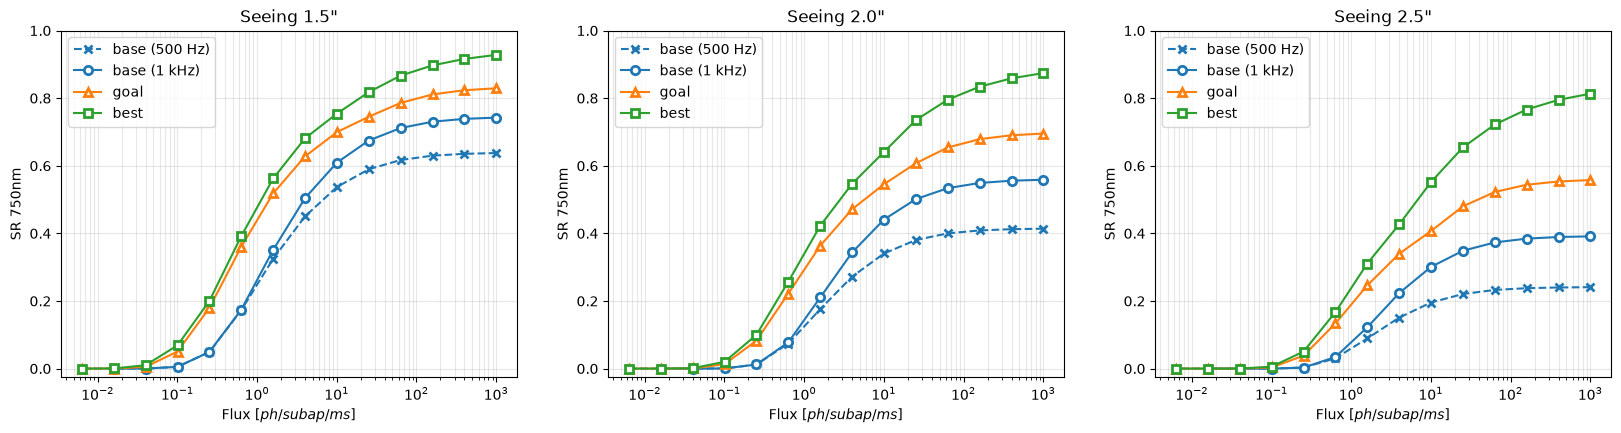

In [11]:
plt.figure(figsize=(20,4.5))
for idx in range(3):
    plt.subplot(1,3,idx+1)
    plt.semilogx(vv_base[idx],sr(tot_base[idx],750), marker='x',linestyle='--',
                    markerfacecolor='white',markeredgewidth=2, c='C0',
                     label='base (500 Hz)')
    plt.semilogx(vv_base_f1000[idx],sr(tot_base_f1000[idx],750), marker='o',linestyle='-',
                    markerfacecolor='white', c='C0',
                    markeredgewidth=2, label='base (1 kHz)')
    plt.semilogx(vv_goal[idx],sr(tot_goal[idx],750), marker='^',linestyle='-',
                    markerfacecolor='white', c='C1',
                    markeredgewidth=2,label='goal')
    plt.semilogx(vv_best[idx],sr(tot_best[idx],750), marker='s',linestyle='-',
                    markerfacecolor='white', c='C2',
                    markeredgewidth=2, label='best')
    plt.legend(loc='best')
    plt.xlabel(r'Flux $[ph/subap/ms]$')
    plt.ylabel('SR 750nm')
    plt.grid(which='both',alpha=0.3)
    plt.ylim([-0.025,1])
    plt.title(f'Seeing {seeings[idx]:1.1f}"')